# Monte Carlo Simulation of a Lennard-Jones Fluid

## Overview

This notebook implements a Monte Carlo (Metropolis) simulation of a system of 108 particles interacting via the Lennard-Jones potential inside a cubic box of length 19 Å.

The objectives are:
- Generate a physically valid initial configuration
- Compute system energy using pairwise interactions
- Perform Monte Carlo updates using the Metropolis criterion
- Analyze the system using statistical observables

---

## Physical Model

### System Description
- Number of particles: 108
- Box size: 19 Å × 19 Å × 19 Å
- Boundary condition: Periodic Boundary Conditions (PBC)
- Minimum allowed distance: rᵢⱼ ≥ 3 Å

---

### Interaction Potential (Lennard-Jones)

The interaction between particles is given by:

\[
U(r) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6 \right]
\]

- The first term represents short-range repulsion  
- The second term represents intermediate-range attraction  

---

### Periodic Boundary Conditions

To eliminate boundary effects, the system is treated as infinitely repeating in all directions.

The minimum image convention is used so that each particle interacts with the nearest periodic image of every other particle.

---

## Initialization

Particles are placed randomly within the simulation box such that:
- No two particles are closer than 3 Å
- This avoids unphysical overlaps in the initial configuration

---

## Monte Carlo Method (Metropolis Algorithm)

Each Monte Carlo step consists of:

1. Selecting a random particle  
2. Proposing a random displacement within [-δ, δ]  
3. Applying periodic boundary conditions  
4. Checking the minimum distance constraint  
5. Computing the energy change ΔE  
6. Accepting or rejecting the move using:

\[
P = \min(1, e^{-\beta \Delta E})
\]

- Moves with ΔE < 0 are always accepted  
- Otherwise, moves are accepted probabilistically  

---

## Observables and Analysis

### Energy vs Monte Carlo Steps
- Tracks how the system evolves over time  
- Stabilization indicates convergence toward equilibrium  

---

### Acceptance Ratio
- Fraction of accepted moves  
- Reflects efficiency of the chosen displacement size  

Typical desirable range: 0.3 to 0.6  

---

### Radial Distribution Function g(r)

Describes how particle density varies with distance:

- Peaks indicate preferred interparticle spacing  
- The first peak corresponds to nearest neighbors  
- g(r) approaches 1 at large distances for a uniform system  

---

### Energy Histogram (Optional)
- Shows distribution of sampled energy values  
- Provides insight into fluctuations and stability  

---

## Key Insights

- The Lennard-Jones potential captures essential features of particle interactions  
- Monte Carlo sampling enables exploration of configuration space  
- Periodic boundary conditions approximate bulk behavior  
- The radial distribution function reveals structural organization  

---

## Possible Extensions

- Study of temperature dependence  
- Comparison with molecular dynamics simulations  
- Implementation of neighbor lists for optimization  
- Visualization of particle configurations in 3D  

---

## Conclusion

This simulation demonstrates how computational methods and statistical mechanics can be applied to study many-particle systems and extract meaningful physical properties.

In [14]:
import numpy as np

In [15]:
N = 108                 # number of particles
L = 19.0                # box length (angstrom)
min_dist = 3.0          # minimum allowed distance
epsilon = 1.0           # LJ parameter
sigma = 1.0             # LJ parameter
beta = 1.0              # 1/kT (reduced units)
delta = 0.5             # max displacement

In [16]:
def minimum_image(rij, box_length):
    return rij - box_length * np.round(rij / box_length)

In [17]:
def distance(r1, r2, box_length):
    rij = r1 - r2
    rij = minimum_image(rij, box_length)
    return np.linalg.norm(rij)

In [18]:

def initialize_positions(N, L, min_dist):
    positions = []
    
    while len(positions) < N:
        trial = np.random.uniform(0, L, 3)
        
        valid = True
        for pos in positions:
            if distance(trial, pos, L) < min_dist:
                valid = False
                break
        
        if valid:
            positions.append(trial)
    
    return np.array(positions)

In [19]:
positions = initialize_positions(N, L, min_dist)

In [20]:
def lennard_jones(r, epsilon=1.0, sigma=1.0):
    if r == 0:
        return 0
    sr6 = (sigma / r)**6
    sr12 = sr6**2
    return 4 * epsilon * (sr12 - sr6)

In [21]:
def total_energy(positions, L):
    E = 0.0
    N = len(positions)
    
    for i in range(N):
        for j in range(i+1, N):
            r = distance(positions[i], positions[j], L)
            E += lennard_jones(r)
    
    return E

In [22]:
E_initial = total_energy(positions, L)
print("Initial Energy:", E_initial)

Initial Energy: -0.6765191117574733


In [23]:
def monte_carlo_step(positions, L, beta, delta, min_dist):
    N = len(positions)
    
    # Choose random particle
    i = np.random.randint(N)
    
    old_pos = positions[i].copy()
    
    # Compute old energy contribution
    old_energy = 0.0
    for j in range(N):
        if j != i:
            r = distance(old_pos, positions[j], L)
            old_energy += lennard_jones(r)
    
    # Trial move
    displacement = np.random.uniform(-delta, delta, 3)
    new_pos = old_pos + displacement
    
    # Apply PBC
    new_pos = new_pos % L
    
    # Check minimum distance constraint
    for j in range(N):
        if j != i:
            if distance(new_pos, positions[j], L) < min_dist:
                return positions, False  # reject immediately
    
    # Compute new energy contribution
    new_energy = 0.0
    for j in range(N):
        if j != i:
            r = distance(new_pos, positions[j], L)
            new_energy += lennard_jones(r)
    
    dE = new_energy - old_energy
    
    # Metropolis criterion
    if dE < 0 or np.random.rand() < np.exp(-beta * dE):
        positions[i] = new_pos
        return positions, True
    else:
        return positions, False

In [24]:
steps = 1000
accepted = 0

for step in range(steps):
    positions, acc = monte_carlo_step(positions, L, beta, delta, min_dist)
    if acc:
        accepted += 1

print("Acceptance ratio:", accepted / steps)

Acceptance ratio: 0.676


In [25]:
E_final = total_energy(positions, L)
print("Final Energy:", E_final)

Final Energy: -0.6677646802124849


In [26]:
import matplotlib.pyplot as plt

steps = 2000
accepted = 0

energy_list = []
acceptance_list = []

E = total_energy(positions, L)

for step in range(steps):
    positions, acc = monte_carlo_step(positions, L, beta, delta, min_dist)
    
    if acc:
        accepted += 1
        E = total_energy(positions, L)  # recompute only on accept (simple version)
    
    energy_list.append(E)
    acceptance_list.append(accepted / (step + 1))

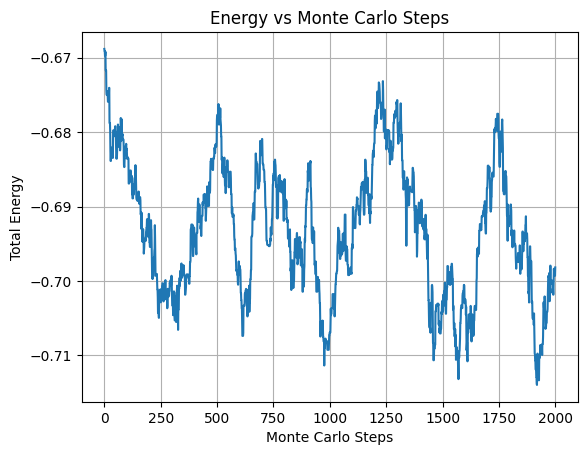

In [27]:
plt.figure()
plt.plot(energy_list)
plt.xlabel("Monte Carlo Steps")
plt.ylabel("Total Energy")
plt.title("Energy vs Monte Carlo Steps")
plt.grid()
plt.show()

In [30]:
def radial_distribution(positions, L, dr=0.1):
    N = len(positions)
    rho = N / (L**3)
    
    r_max = L / 2
    bins = np.arange(0, r_max + dr, dr)   # include endpoint
    g_r = np.zeros(len(bins) - 1)
    
    for i in range(N):
        for j in range(i+1, N):
            r = distance(positions[i], positions[j], L)
            
            if r < r_max:
                bin_index = int(np.floor(r / dr))
                
                # prevent overflow
                if bin_index < len(g_r):
                    g_r[bin_index] += 2
    
    # Normalize
    r_values = (bins[:-1] + bins[1:]) / 2
    
    for i in range(len(g_r)):
        r_outer = bins[i+1]
        r_inner = bins[i]
        shell_volume = (4/3) * np.pi * (r_outer**3 - r_inner**3)
        
        ideal = rho * shell_volume * N
        if ideal > 0:
            g_r[i] /= ideal
    
    return r_values, g_r

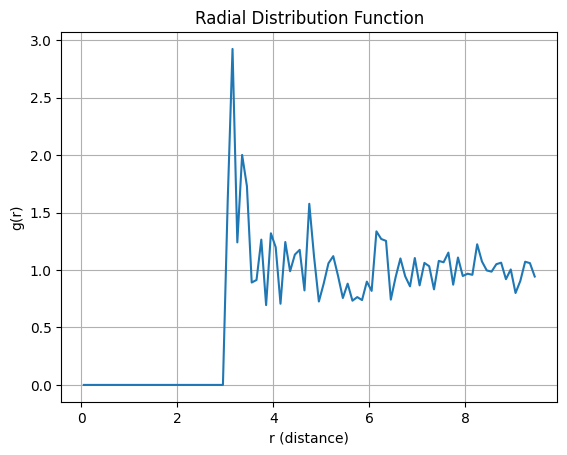

In [31]:
r_vals, g_vals = radial_distribution(positions, L)

plt.figure()
plt.plot(r_vals, g_vals)
plt.xlabel("r (distance)")
plt.ylabel("g(r)")
plt.title("Radial Distribution Function")
plt.grid()
plt.show()

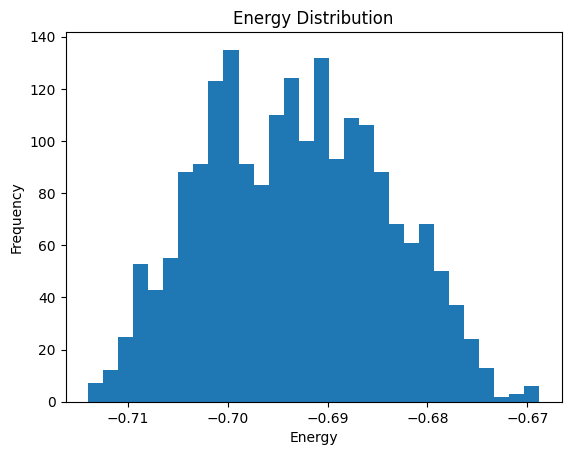

In [32]:
plt.figure()
plt.hist(energy_list, bins=30)
plt.xlabel("Energy")
plt.ylabel("Frequency")
plt.title("Energy Distribution")
plt.show()